## ***Lab Report 2***

### ***Part 1***

PDLS trials found: 10
DDLS trials found: 10


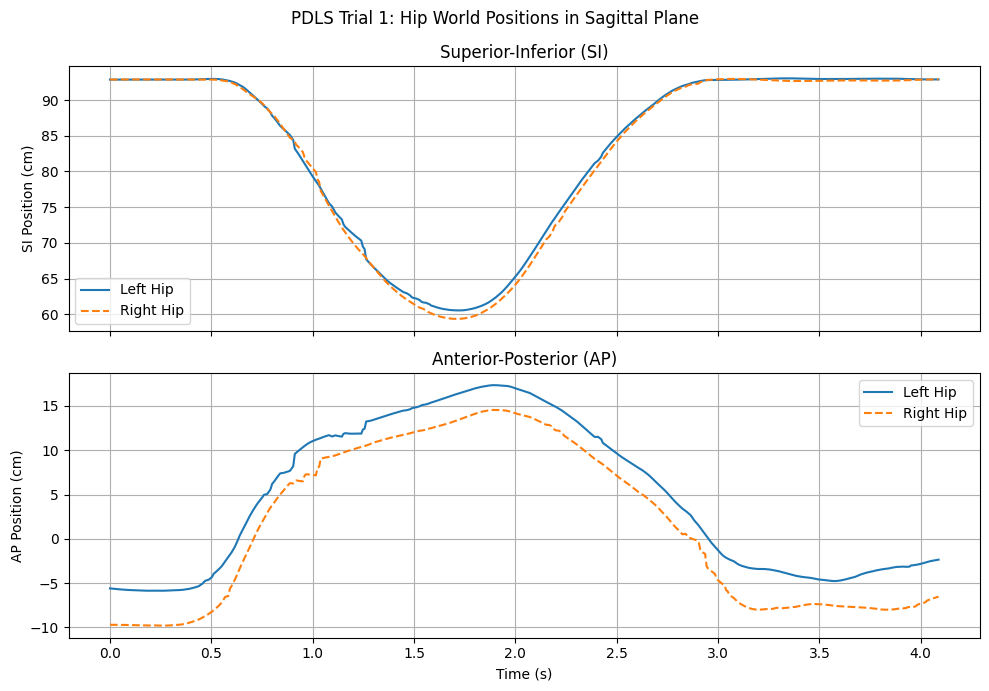

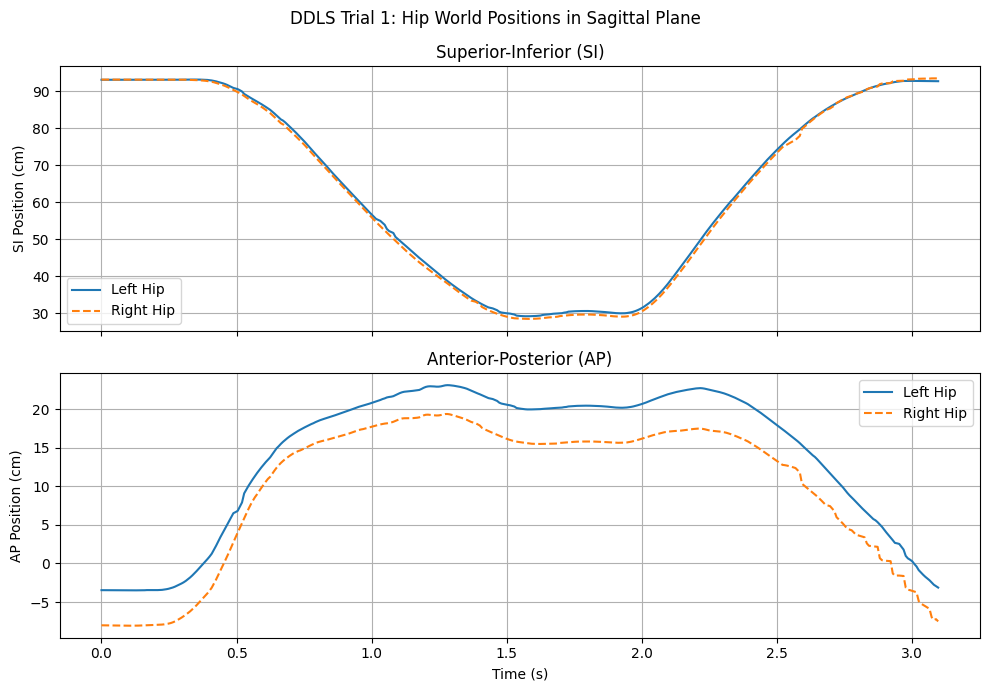

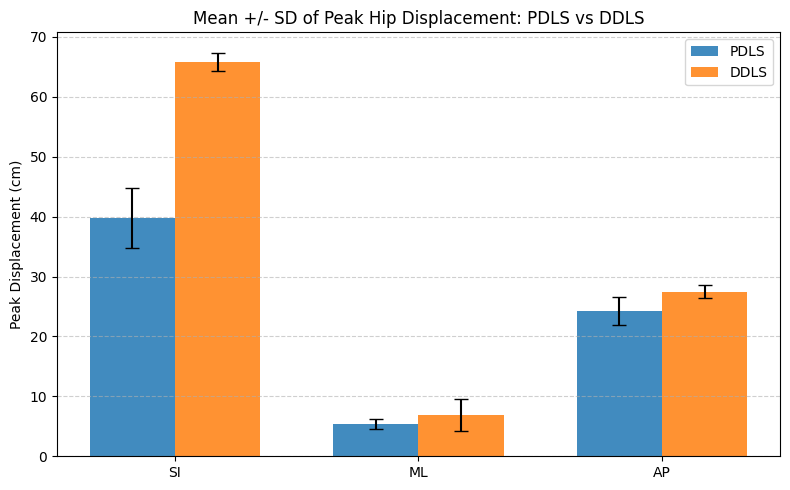

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import glob
import os
import bvhio

# ── bvhio-based world-space position loader ──────────────────────────────────
def load_joint_world_pos(filepath, joint_names):
    """
    Returns world-space positions for each named joint across all frames.
    Axis mapping (bvhio/OpenGL right-handed, Y+ up, Z- forward):
      X -> ML,  Y -> SI,  Z -> AP
    Result dict: {joint_name: ndarray shape (n_frames, 3)}
    """
    bvh_meta = bvhio.readAsBvh(filepath)
    n_frames = bvh_meta.FrameCount
    ft = bvh_meta.FrameTime

    root = bvhio.readAsHierarchy(filepath)
    joints = {name: root.filter(name)[0] for name in joint_names}

    positions = {name: np.zeros((n_frames, 3)) for name in joint_names}
    for i in range(n_frames):
        root.loadPose(i)
        for name, jnt in joints.items():
            p = jnt.PositionWorld
            positions[name][i] = [p.x, p.y, p.z]

    return np.arange(n_frames) * ft, positions, ft


def peak_displacements(files):
    """Peak displacement per trial = range (max-min), averaged L & R hip world positions."""
    si_peaks, ml_peaks, ap_peaks = [], [], []
    for fp in files:
        _, pos, _ = load_joint_world_pos(fp, ["LeftUpLeg", "RightUpLeg"])
        left, right = pos["LeftUpLeg"], pos["RightUpLeg"]
        si_peaks.append((np.ptp(left[:, 1]) + np.ptp(right[:, 1])) / 2.0)   # Y = SI
        ml_peaks.append((np.ptp(left[:, 0]) + np.ptp(right[:, 0])) / 2.0)   # X = ML
        ap_peaks.append((np.ptp(left[:, 2]) + np.ptp(right[:, 2])) / 2.0)   # Z = AP
    return np.array(si_peaks), np.array(ml_peaks), np.array(ap_peaks)


def summarize(peaks):
    return {
        "SI_mean": np.mean(peaks[0]), "SI_std": np.std(peaks[0]),
        "ML_mean": np.mean(peaks[1]), "ML_std": np.std(peaks[1]),
        "AP_mean": np.mean(peaks[2]), "AP_std": np.std(peaks[2]),
    }

# Motion 1 = PDLS, Motion 2 = DDLS
data_dir = "data"
pdls_files = sorted(glob.glob(os.path.join(data_dir, "motion_1_*.bvh")))
ddls_files = sorted(glob.glob(os.path.join(data_dir, "motion_2_*.bvh")))

print(f"PDLS trials found: {len(pdls_files)}")
print(f"DDLS trials found: {len(ddls_files)}")

unit_label = "cm"

# (a) PDLS trial 1 - sagittal plane (SI and AP), world positions
t1, pos1, _ = load_joint_world_pos(pdls_files[0], ["LeftUpLeg", "RightUpLeg"])

fig, axes = plt.subplots(2, 1, figsize=(10, 7), sharex=True)
fig.suptitle("PDLS Trial 1: Hip World Positions in Sagittal Plane")

axes[0].plot(t1, pos1["LeftUpLeg"][:, 1],  label="Left Hip",  color="tab:blue")
axes[0].plot(t1, pos1["RightUpLeg"][:, 1], label="Right Hip", color="tab:orange", linestyle="--")
axes[0].set_ylabel(f"SI Position ({unit_label})")
axes[0].set_title("Superior-Inferior (SI)")
axes[0].legend(); axes[0].grid(True)

axes[1].plot(t1, pos1["LeftUpLeg"][:, 2],  label="Left Hip",  color="tab:blue")
axes[1].plot(t1, pos1["RightUpLeg"][:, 2], label="Right Hip", color="tab:orange", linestyle="--")
axes[1].set_ylabel(f"AP Position ({unit_label})")
axes[1].set_xlabel("Time (s)")
axes[1].set_title("Anterior-Posterior (AP)")
axes[1].legend(); axes[1].grid(True)

plt.tight_layout(); plt.show()

# (b) DDLS trial 1
t2, pos2, _ = load_joint_world_pos(ddls_files[0], ["LeftUpLeg", "RightUpLeg"])

fig, axes = plt.subplots(2, 1, figsize=(10, 7), sharex=True)
fig.suptitle("DDLS Trial 1: Hip World Positions in Sagittal Plane")

axes[0].plot(t2, pos2["LeftUpLeg"][:, 1],  label="Left Hip",  color="tab:blue")
axes[0].plot(t2, pos2["RightUpLeg"][:, 1], label="Right Hip", color="tab:orange", linestyle="--")
axes[0].set_ylabel(f"SI Position ({unit_label})")
axes[0].set_title("Superior-Inferior (SI)")
axes[0].legend(); axes[0].grid(True)

axes[1].plot(t2, pos2["LeftUpLeg"][:, 2],  label="Left Hip",  color="tab:blue")
axes[1].plot(t2, pos2["RightUpLeg"][:, 2], label="Right Hip", color="tab:orange", linestyle="--")
axes[1].set_ylabel(f"AP Position ({unit_label})")
axes[1].set_xlabel("Time (s)")
axes[1].set_title("Anterior-Posterior (AP)")
axes[1].legend(); axes[1].grid(True)

plt.tight_layout(); plt.show()

# (c) Mean and SD of peak displacement over all 10 trials
pdls_peaks = peak_displacements(pdls_files)
ddls_peaks = peak_displacements(ddls_files)
pdls_stats = summarize(pdls_peaks)
ddls_stats = summarize(ddls_peaks)

# Bar chart
directions = ["SI", "ML", "AP"]
pdls_means = [pdls_stats["SI_mean"], pdls_stats["ML_mean"], pdls_stats["AP_mean"]]
pdls_stds  = [pdls_stats["SI_std"],  pdls_stats["ML_std"],  pdls_stats["AP_std"]]
ddls_means = [ddls_stats["SI_mean"], ddls_stats["ML_mean"], ddls_stats["AP_mean"]]
ddls_stds  = [ddls_stats["SI_std"],  ddls_stats["ML_std"],  ddls_stats["AP_std"]]

x = np.arange(len(directions))
w = 0.35

fig, ax = plt.subplots(figsize=(8, 5))
ax.bar(x - w/2, pdls_means, w, yerr=pdls_stds, capsize=5, label="PDLS", color="tab:blue", alpha=0.85)
ax.bar(x + w/2, ddls_means, w, yerr=ddls_stds, capsize=5, label="DDLS", color="tab:orange", alpha=0.85)
ax.set_xticks(x); ax.set_xticklabels(directions)
ax.set_ylabel(f"Peak Displacement ({unit_label})")
ax.set_title("Mean +/- SD of Peak Hip Displacement: PDLS vs DDLS")
ax.legend(); ax.grid(axis="y", linestyle="--", alpha=0.6)
plt.tight_layout(); plt.show()

TODO: Answer d, e

### ***Part 2***

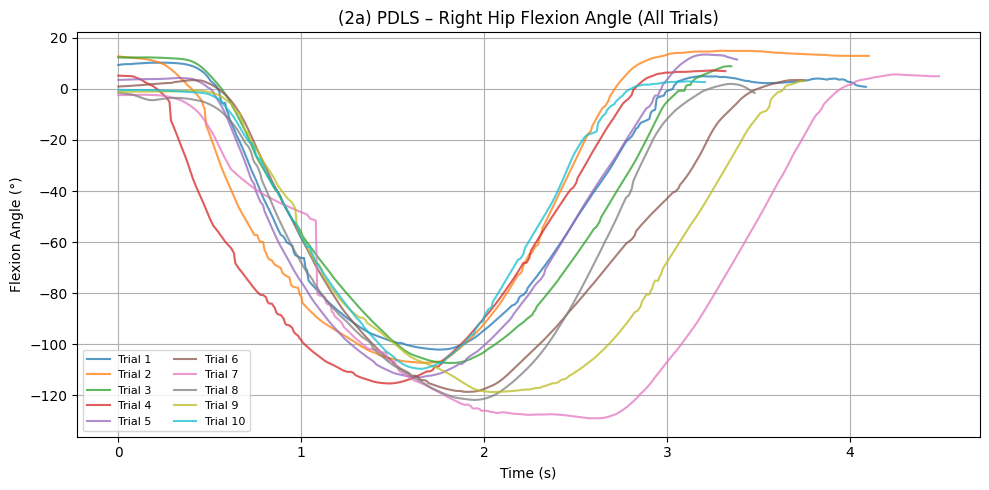

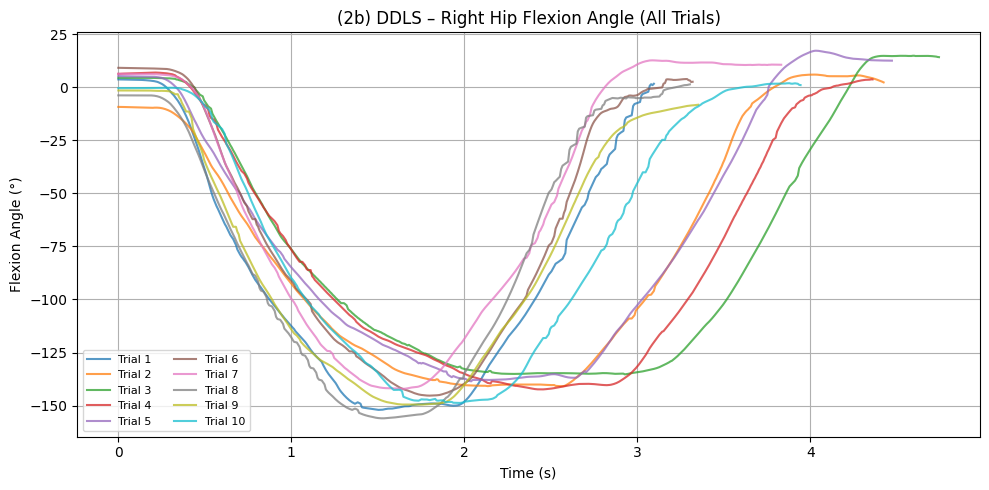

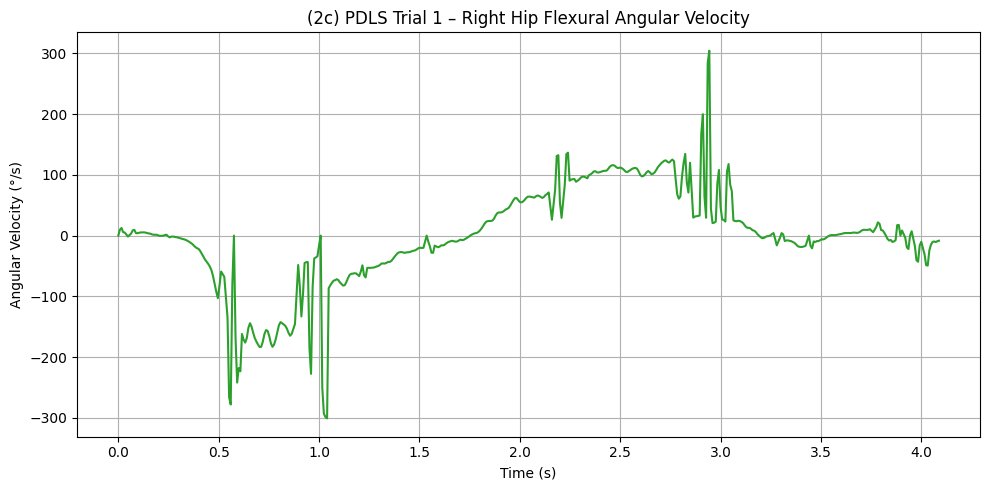

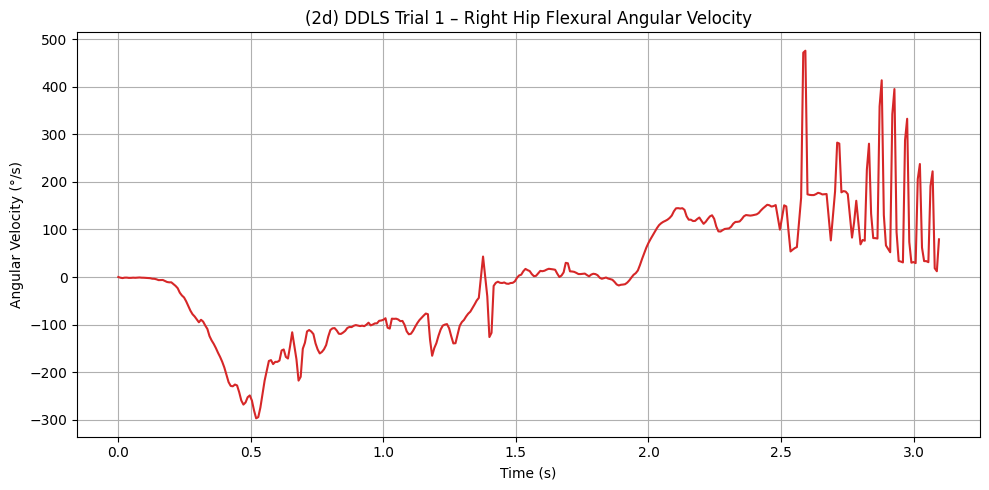

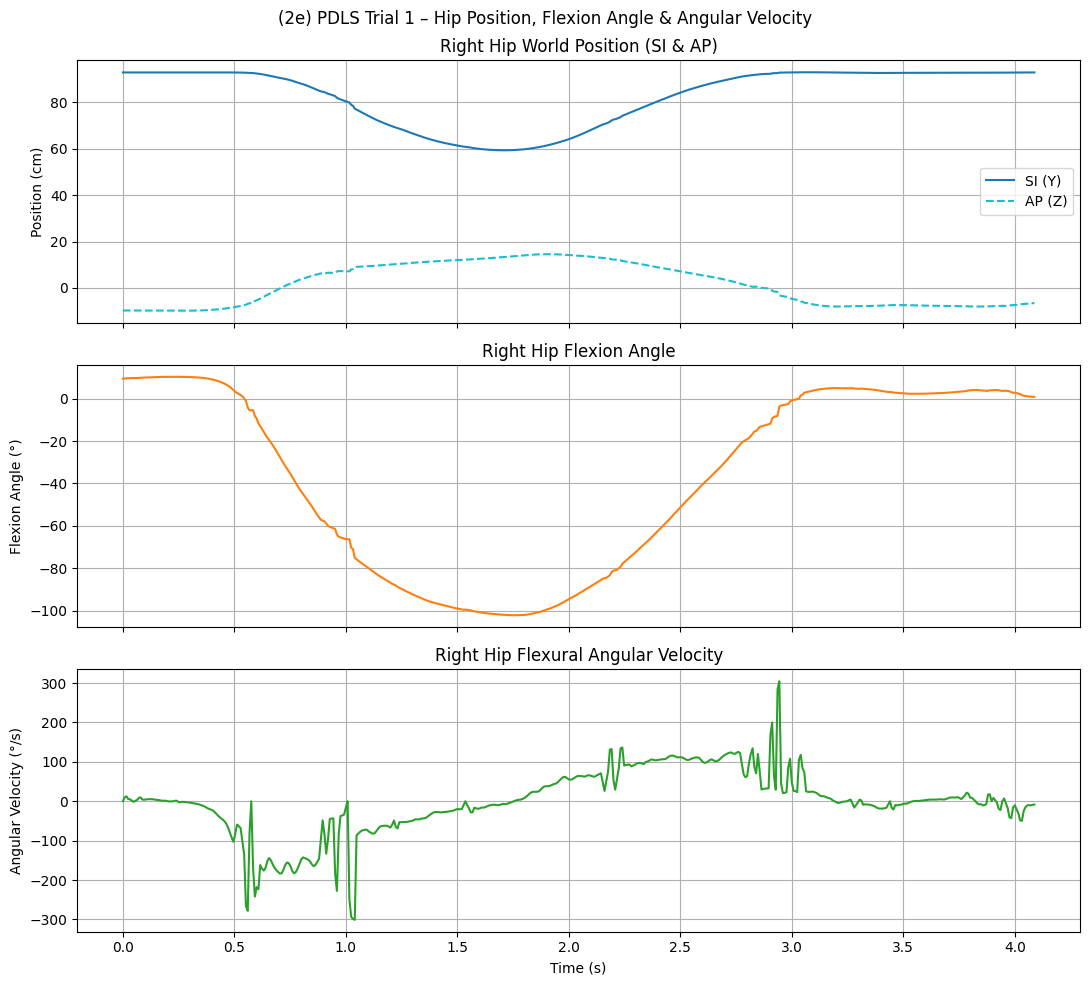

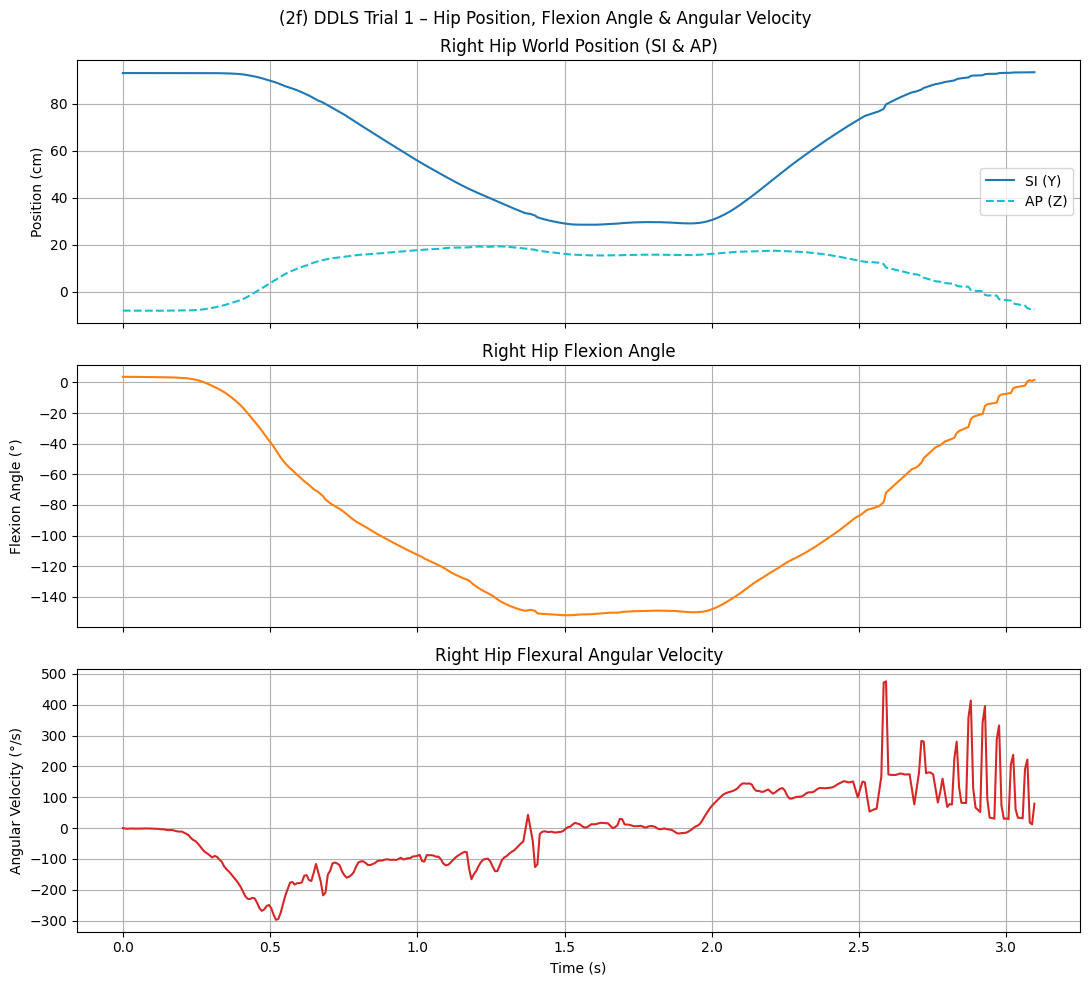

In [ ]:
import glm

def load_joint_xrot(filepath, joint_name):
    """Returns (time, xrotation_deg, frame_time) for a named joint via bvhio."""
    bvh = bvhio.readAsBvh(filepath)
    ft = bvh.FrameTime

    def find_joint(j, name):
        if j.Name == name: return j
        for c in j.Children:
            r = find_joint(c, name)
            if r: return r

    joint = find_joint(bvh.Root, joint_name)
    angles = np.array([glm.degrees(glm.eulerAngles(kf.Rotation)).x
                       for kf in joint.Keyframes])
    return np.arange(len(angles)) * ft, angles, ft


# ── (a) Right hip flexion angle - all PDLS trials ───────────────────────────
fig, ax = plt.subplots(figsize=(10, 5))
for i, fp in enumerate(pdls_files):
    t, flex, _ = load_joint_xrot(fp, "RightUpLeg")
    ax.plot(t, flex, alpha=0.75, label=f"Trial {i+1}")
ax.set_title("(2a) PDLS - Right Hip Flexion Angle (All Trials)")
ax.set_xlabel("Time (s)"); ax.set_ylabel("Flexion Angle (°)")
ax.legend(ncol=2, fontsize=8); ax.grid(True)
plt.tight_layout(); plt.show()


# ── (b) Right hip flexion angle - all DDLS trials ───────────────────────────
fig, ax = plt.subplots(figsize=(10, 5))
for i, fp in enumerate(ddls_files):
    t, flex, _ = load_joint_xrot(fp, "RightUpLeg")
    ax.plot(t, flex, alpha=0.75, label=f"Trial {i+1}")
ax.set_title("(2b) DDLS - Right Hip Flexion Angle (All Trials)")
ax.set_xlabel("Time (s)"); ax.set_ylabel("Flexion Angle (°)")
ax.legend(ncol=2, fontsize=8); ax.grid(True)
plt.tight_layout(); plt.show()


# ── (c) Right hip flexural angular velocity - representative PDLS trial ─────
rep_pdls = pdls_files[0]
t_p, flex_p, ft_p = load_joint_xrot(rep_pdls, "RightUpLeg")
angvel_p = np.gradient(flex_p, ft_p)

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(t_p, angvel_p, color="tab:green")
ax.set_title("(2c) PDLS Trial 1 - Right Hip Flexural Angular Velocity")
ax.set_xlabel("Time (s)"); ax.set_ylabel("Angular Velocity (°/s)")
ax.grid(True); plt.tight_layout(); plt.show()


# ── (d) Right hip flexural angular velocity - representative DDLS trial ─────
rep_ddls = ddls_files[0]
t_d, flex_d, ft_d = load_joint_xrot(rep_ddls, "RightUpLeg")
angvel_d = np.gradient(flex_d, ft_d)

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(t_d, angvel_d, color="tab:red")
ax.set_title("(2d) DDLS Trial 1 - Right Hip Flexural Angular Velocity")
ax.set_xlabel("Time (s)"); ax.set_ylabel("Angular Velocity (°/s)")
ax.grid(True); plt.tight_layout(); plt.show()


# ── (e) PDLS - angular velocity vs. world position & flexion angle ──────────
_, pos_p, _ = load_joint_world_pos(rep_pdls, ["RightUpLeg"])
R_p_si = pos_p["RightUpLeg"][:, 1]
R_p_ap = pos_p["RightUpLeg"][:, 2]

fig, axes = plt.subplots(3, 1, figsize=(11, 10), sharex=True)
fig.suptitle("(2e) PDLS Trial 1 - Hip Position, Flexion Angle & Angular Velocity")
axes[0].plot(t_p, R_p_si, color="tab:blue",  label="SI (Y)")
axes[0].plot(t_p, R_p_ap, color="tab:cyan", linestyle="--", label="AP (Z)")
axes[0].set_ylabel("Position (cm)"); axes[0].set_title("Right Hip World Position (SI & AP)")
axes[0].legend(); axes[0].grid(True)
axes[1].plot(t_p, flex_p, color="tab:orange")
axes[1].set_ylabel("Flexion Angle (°)"); axes[1].set_title("Right Hip Flexion Angle")
axes[1].grid(True)
axes[2].plot(t_p, angvel_p, color="tab:green")
axes[2].set_ylabel("Angular Velocity (°/s)"); axes[2].set_xlabel("Time (s)")
axes[2].set_title("Right Hip Flexural Angular Velocity"); axes[2].grid(True)
plt.tight_layout(); plt.show()


# ── (f) DDLS - angular velocity vs. world position & flexion angle ──────────
_, pos_d, _ = load_joint_world_pos(rep_ddls, ["RightUpLeg"])
R_d_si = pos_d["RightUpLeg"][:, 1]
R_d_ap = pos_d["RightUpLeg"][:, 2]

fig, axes = plt.subplots(3, 1, figsize=(11, 10), sharex=True)
fig.suptitle("(2f) DDLS Trial 1 - Hip Position, Flexion Angle & Angular Velocity")
axes[0].plot(t_d, R_d_si, color="tab:blue",  label="SI (Y)")
axes[0].plot(t_d, R_d_ap, color="tab:cyan", linestyle="--", label="AP (Z)")
axes[0].set_ylabel("Position (cm)"); axes[0].set_title("Right Hip World Position (SI & AP)")
axes[0].legend(); axes[0].grid(True)
axes[1].plot(t_d, flex_d, color="tab:orange")
axes[1].set_ylabel("Flexion Angle (°)"); axes[1].set_title("Right Hip Flexion Angle")
axes[1].grid(True)
axes[2].plot(t_d, angvel_d, color="tab:red")
axes[2].set_ylabel("Angular Velocity (°/s)"); axes[2].set_xlabel("Time (s)")
axes[2].set_title("Right Hip Flexural Angular Velocity"); axes[2].grid(True)
plt.tight_layout(); plt.show()

### ***Part 3***

3a) Angular Velocity Addition Theorem - Equations & Sample Calculation

  Theorem:
    ^G ω_shank = ^G ω_thigh  +  ^thigh ω_shank

  Solving for knee angular velocity (ThighωShank):
    ThighωShank = ^G ω_shank - ^G ω_thigh

  BVH sagittal-plane implementation:
    θ_thigh(t)      = Xrotation(RightUpLeg)
    θ_knee_local(t) = Xrotation(RightLeg)
    θ_shank_abs(t)  = θ_thigh(t) + θ_knee_local(t)
    ω_thigh(t)      = [θ_thigh(t) - θ_thigh(t-Δt)] / Δt
    ω_shank(t)      = [θ_shank_abs(t) - θ_shank_abs(t-Δt)] / Δt
    ThighωShank(t)  = ω_shank(t) - ω_thigh(t)

  Frame time  Δt = 0.00800 s  (125.00 Hz)

  Sample calculation at squat-start frame 66  (t = 0.5280 s):
    θ_thigh[66]        = 1.6696 °
    θ_shank_abs[66]    = 6.4395 °
    ω_thigh   = (1.6696 - 2.1930) / 0.00800 = -65.4158 °/s
    ω_shank   = (6.4395 - 6.3004) / 0.00800 = 17.3828 °/s
    ThighωShank = 17.3828 - -65.4158 = 82.7986 °/s

  First 10 rows from squat start - PDLS Trial 1 (Char00):
 Frame Time (s) θ_thigh (°) θ_knee

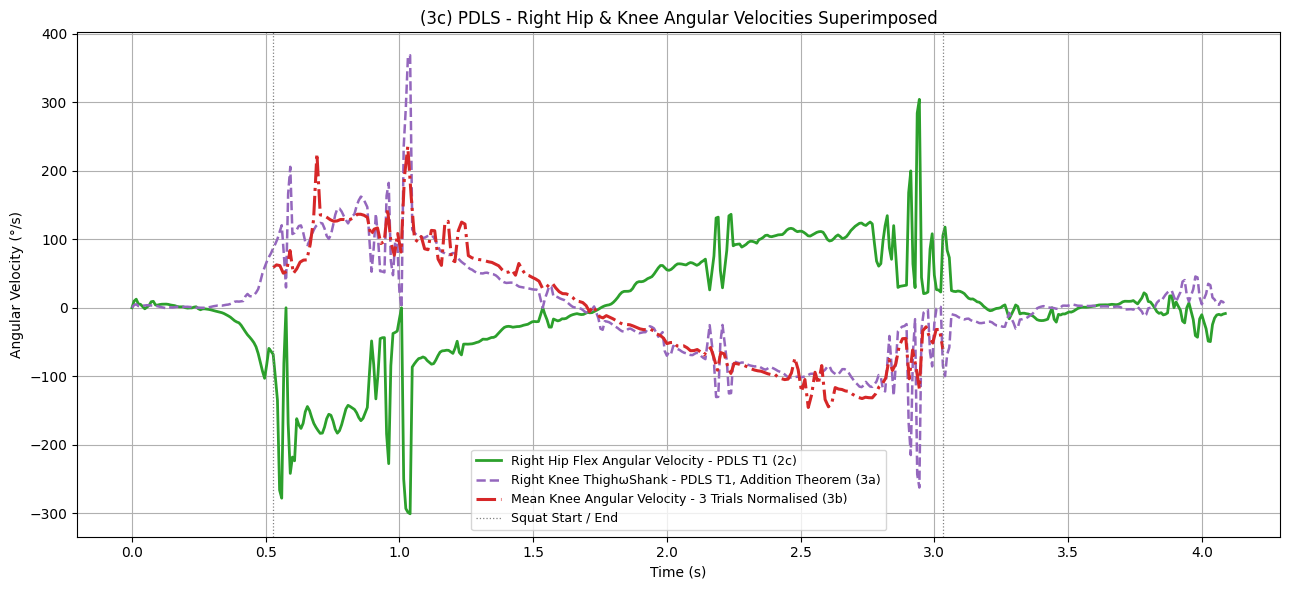

In [17]:
import pandas as pd

# ─────────────────────────────────────────────────────────────────────────────
# 3a) Right knee flexural angular velocity - angular velocity addition theorem
# ─────────────────────────────────────────────────────────────────────────────
#
#  Angular Velocity Addition Theorem (vector form):
#    ^G ω_shank = ^G ω_thigh  +  ^thigh ω_shank
#
#  Solving for the knee (ThighωShank ≡ ^thigh ω_shank):
#    ThighωShank = ^G ω_shank - ^G ω_thigh
#
#  Sagittal-plane implementation with BVH local Euler angles:
#    θ_thigh(t)      = Xrotation(RightUpLeg)              [hip flexion, °]
#    θ_knee_local(t) = Xrotation(RightLeg)                [knee local, °]
#    θ_shank_abs(t)  = θ_thigh(t) + θ_knee_local(t)       [abs shank angle, °]
#    ω_thigh(t)      = dθ_thigh/dt                        [°/s]
#    ω_shank(t)      = dθ_shank_abs/dt                    [°/s]
#    ThighωShank(t)  = ω_shank(t) - ω_thigh(t)            [°/s]
#                    = d[θ_knee_local(t)]/dt              [°/s]
#
#  NOTE on bvhio use:
#    load_joint_xrot() reads bvhio BvhJoint.Keyframes[i].Rotation (quaternion),
#    converts to Euler with glm.eulerAngles(), then to degrees with glm.degrees(),
#    and returns the X component.
# ─────────────────────────────────────────────────────────────────────────────

# Trial 1 (PDLS): get thigh and knee X rotations from bvhio-based loader
t3, theta_thigh, ft3 = load_joint_xrot(pdls_files[0], "RightUpLeg")
_,  theta_knee_local, _ = load_joint_xrot(pdls_files[0], "RightLeg")

theta_shank_abs = theta_thigh + theta_knee_local

omega_thigh   = np.gradient(theta_thigh, ft3)       # °/s
omega_shank   = np.gradient(theta_shank_abs, ft3)   # °/s
thigh_w_shank = omega_shank - omega_thigh           # knee angular velocity °/s


# ── Squat-boundary detector ──────────────────────────────────────────────────
def find_squat_bounds(flex_angle, threshold_pct=0.05, baseline_frames=10):
    """Return (start_frame, end_frame) for the squat motion."""
    baseline  = flex_angle[:baseline_frames].mean()
    threshold = threshold_pct * np.ptp(flex_angle)
    active    = np.where(np.abs(flex_angle - baseline) > threshold)[0]
    if len(active) == 0:
        return 0, len(flex_angle) - 1
    return int(active[0]), int(active[-1])


squat_start, squat_end = find_squat_bounds(theta_knee_local)

# ── Print equations & sample calculation ────────────────────────────────────
print("=" * 68)
print("3a) Angular Velocity Addition Theorem - Equations & Sample Calculation")
print("=" * 68)
print()
print("  Theorem:")
print("    ^G ω_shank = ^G ω_thigh  +  ^thigh ω_shank")
print()
print("  Solving for knee angular velocity (ThighωShank):")
print("    ThighωShank = ^G ω_shank - ^G ω_thigh")
print()
print("  BVH sagittal-plane implementation:")
print("    θ_thigh(t)      = Xrotation(RightUpLeg)")
print("    θ_knee_local(t) = Xrotation(RightLeg)")
print("    θ_shank_abs(t)  = θ_thigh(t) + θ_knee_local(t)")
print("    ω_thigh(t)      = [θ_thigh(t) - θ_thigh(t-Δt)] / Δt")
print("    ω_shank(t)      = [θ_shank_abs(t) - θ_shank_abs(t-Δt)] / Δt")
print("    ThighωShank(t)  = ω_shank(t) - ω_thigh(t)")
print(f"\n  Frame time  Δt = {ft3:.5f} s  ({1.0/ft3:.2f} Hz)")
print()

i = squat_start
if i > 0:
    ow_t_s = (theta_thigh[i]     - theta_thigh[i - 1])     / ft3
    ow_s_s = (theta_shank_abs[i] - theta_shank_abs[i - 1]) / ft3
else:
    ow_t_s = omega_thigh[i]
    ow_s_s = omega_shank[i]
tws_s = ow_s_s - ow_t_s

prev = max(0, i - 1)
print(f"  Sample calculation at squat-start frame {i}  (t = {t3[i]:.4f} s):")
print(f"    θ_thigh[{i}]        = {theta_thigh[i]:.4f} °")
print(f"    θ_shank_abs[{i}]    = {theta_shank_abs[i]:.4f} °")
print(f"    ω_thigh   = ({theta_thigh[i]:.4f} - {theta_thigh[prev]:.4f}) / {ft3:.5f}"
      f" = {ow_t_s:.4f} °/s")
print(f"    ω_shank   = ({theta_shank_abs[i]:.4f} - {theta_shank_abs[prev]:.4f}) / {ft3:.5f}"
      f" = {ow_s_s:.4f} °/s")
print(f"    ThighωShank = {ow_s_s:.4f} - {ow_t_s:.4f} = {tws_s:.4f} °/s")
print()

# ── Table: first 10 rows from squat start ────────────────────────────────────
rows = range(squat_start, min(squat_start + 10, len(t3)))
df_3a = pd.DataFrame({
    "Frame":              list(rows),
    "Time (s)":           [f"{t3[r]:.4f}"                for r in rows],
    "θ_thigh (°)":        [f"{theta_thigh[r]:.4f}"       for r in rows],
    "θ_knee_local (°)":   [f"{theta_knee_local[r]:.4f}"  for r in rows],
    "θ_shank_abs (°)":    [f"{theta_shank_abs[r]:.4f}"   for r in rows],
    "ω_thigh (°/s)":      [f"{omega_thigh[r]:.4f}"       for r in rows],
    "ω_shank (°/s)":      [f"{omega_shank[r]:.4f}"       for r in rows],
    "ThighωShank (°/s)":  [f"{thigh_w_shank[r]:.4f}"     for r in rows],
})
print("  First 10 rows from squat start - PDLS Trial 1 (Char00):")
print(df_3a.to_string(index=False))
print()

# ─────────────────────────────────────────────────────────────────────────────
# 3b) Normalize time for 3 representative PDLS trials → compute mean
# ─────────────────────────────────────────────────────────────────────────────
rep_trials = [0, 1, 2]
n_norm     = 200
norm_pct   = np.linspace(0, 100, n_norm)
angvel_norm_all = np.zeros((len(rep_trials), n_norm))
squat_info = []

for k, ti in enumerate(rep_trials):
    t_k, kf_k, ft_k = load_joint_xrot(pdls_files[ti], "RightLeg")
    av_k = np.gradient(kf_k, ft_k)
    s_k, e_k = find_squat_bounds(kf_k)

    squat_info.append((t_k, av_k, s_k, e_k))
    print(f"  Trial {ti+1:<2}  {s_k:>12}  {e_k:>9}  "
          f"{t_k[s_k]:>12.4f}  {t_k[e_k]:>9.4f}  {(t_k[e_k]-t_k[s_k]):>12.4f}")

    seg     = av_k[s_k:e_k + 1]
    pct_seg = np.linspace(0, 100, len(seg))
    angvel_norm_all[k] = np.interp(norm_pct, pct_seg, seg)

mean_angvel_norm = angvel_norm_all.mean(axis=0)

# ─────────────────────────────────────────────────────────────────────────────
# 3c) Superimpose on figure from 2(c)
# ─────────────────────────────────────────────────────────────────────────────
# Hip angular velocity for PDLS Trial 1 (reproduces 2c baseline)
flex_hip3   = theta_thigh
angvel_hip3 = np.gradient(flex_hip3, ft3)

# Map normalized mean onto Trial 1 squat window for a common time axis
t_norm_mapped = np.linspace(t3[squat_start], t3[squat_end], n_norm)

fig, ax = plt.subplots(figsize=(13, 6))

ax.plot(t3, angvel_hip3,
        color="tab:green", linewidth=2.0,
        label="Right Hip Flex Angular Velocity - PDLS T1 (2c)")
ax.plot(t3, thigh_w_shank,
        color="tab:purple", linewidth=1.8, linestyle="--",
        label="Right Knee ThighωShank - PDLS T1, Addition Theorem (3a)")
ax.plot(t_norm_mapped, mean_angvel_norm,
        color="tab:red", linewidth=2.2, linestyle="-.",
        label="Mean Knee Angular Velocity - 3 Trials Normalised (3b)")

ax.axvline(t3[squat_start], color="gray", linewidth=0.9, linestyle=":",
           label="Squat Start / End")
ax.axvline(t3[squat_end], color="gray", linewidth=0.9, linestyle=":")

ax.set_title("(3c) PDLS - Right Hip & Knee Angular Velocities Superimposed")
ax.set_xlabel("Time (s)")
ax.set_ylabel("Angular Velocity (°/s)")
ax.legend(fontsize=9)
ax.grid(True)
plt.tight_layout()
plt.show()

# ─────────────────────────────────────────────────────────────────────────────
# 3d) Compare ranges
# ─────────────────────────────────────────────────────────────────────────────
hip_range     = np.ptp(angvel_hip3)
knee_3a_range = np.ptp(thigh_w_shank)
knee_3b_range = np.ptp(mean_angvel_norm)

### ***Part 4***

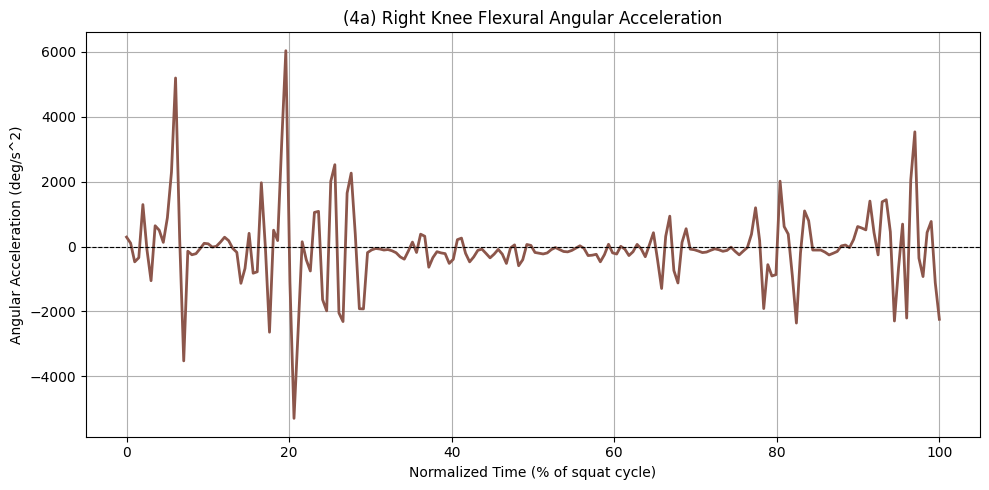

Mean squat duration across 3 trials used for dt_norm: 2.5413 s
dt_norm: 0.012771 s per normalized step
Angular acceleration range: 11325.09 deg/s^2


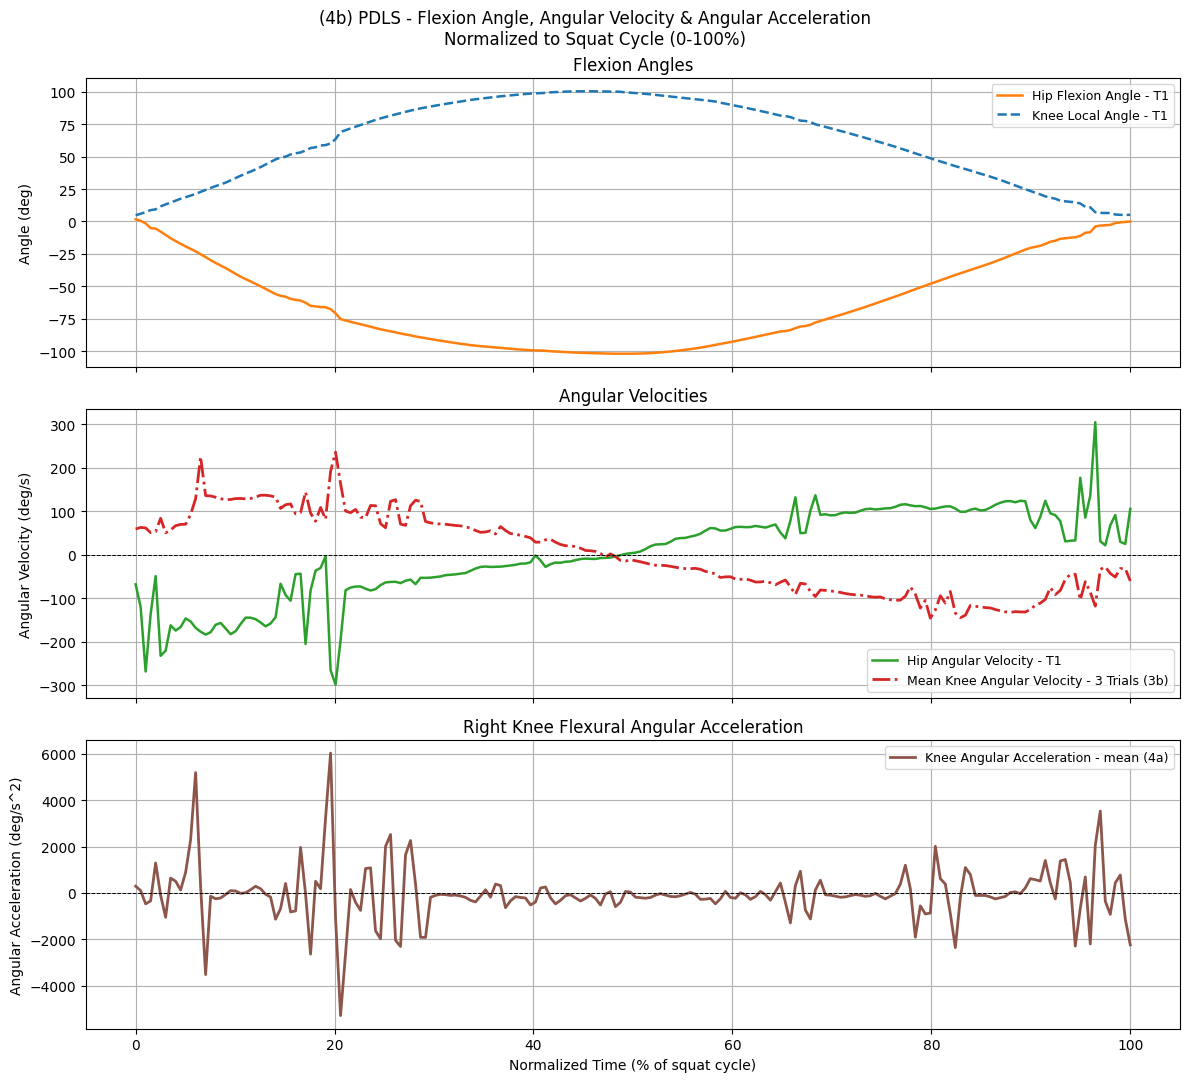

In [20]:
# ─────────────────────────────────────────────────────────────────────────────
# 4a) Right knee flexural angular acceleration from derivative of 3(b) mean
# ─────────────────────────────────────────────────────────────────────────────
# mean_angvel_norm is built from 3 normalized trials in 3b.
# Use the mean squat duration across those same trials to convert normalized step
# spacing to seconds before differentiating.

durations = np.array([info[0][info[3]] - info[0][info[2]] for info in squat_info])  # t_k[e_k]-t_k[s_k]
mean_squat_duration = durations.mean()
dt_norm = mean_squat_duration / (n_norm - 1)   # seconds per normalized step

mean_angacc_norm = np.gradient(mean_angvel_norm, dt_norm)   # deg/s^2

# Plot 4a - angular acceleration of mean normalized knee velocity
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(norm_pct, mean_angacc_norm, color="tab:brown", linewidth=2)
ax.axhline(0, color="black", linewidth=0.8, linestyle="--")
ax.set_title("(4a) Right Knee Flexural Angular Acceleration")
ax.set_xlabel("Normalized Time (% of squat cycle)")
ax.set_ylabel("Angular Acceleration (deg/s^2)")
ax.grid(True)
plt.tight_layout()
plt.show()

print("Mean squat duration across 3 trials used for dt_norm:", f"{mean_squat_duration:.4f} s")
print("dt_norm:", f"{dt_norm:.6f} s per normalized step")
print("Angular acceleration range:", f"{np.ptp(mean_angacc_norm):.2f} deg/s^2")

# ─────────────────────────────────────────────────────────────────────────────
# 4b) Side-by-side comparison: flexion angle | angular velocity | acceleration
# ─────────────────────────────────────────────────────────────────────────────
# Normalize Trial-1 hip/knee quantities onto same 0-100% axis for comparison.

squat_slice = slice(squat_start, squat_end + 1)
flex_norm_pct = np.linspace(0, 100, squat_end - squat_start + 1)

# Hip flexion angle - Trial 1, squat window
hip_flex_seg = flex_hip3[squat_slice]
hip_flex_norm = np.interp(norm_pct, flex_norm_pct, hip_flex_seg)

# Knee local angle - Trial 1, squat window
knee_flex_seg = theta_knee_local[squat_slice]
knee_flex_norm = np.interp(norm_pct, flex_norm_pct, knee_flex_seg)

# Hip angular velocity - Trial 1, squat window
hip_vel_seg = angvel_hip3[squat_slice]
hip_vel_norm = np.interp(norm_pct, flex_norm_pct, hip_vel_seg)

fig, axes = plt.subplots(3, 1, figsize=(12, 11), sharex=True)
fig.suptitle("(4b) PDLS - Flexion Angle, Angular Velocity & Angular Acceleration\n"
             "Normalized to Squat Cycle (0-100%)", fontsize=12)

# Panel 1 - flexion angles
axes[0].plot(norm_pct, hip_flex_norm,
             color="tab:orange", linewidth=1.8, label="Hip Flexion Angle - T1")
axes[0].plot(norm_pct, knee_flex_norm,
             color="tab:blue", linewidth=1.8, linestyle="--", label="Knee Local Angle - T1")
axes[0].set_ylabel("Angle (deg)")
axes[0].set_title("Flexion Angles")
axes[0].legend(fontsize=9)
axes[0].grid(True)

# Panel 2 - angular velocities
axes[1].plot(norm_pct, hip_vel_norm,
             color="tab:green", linewidth=1.8, label="Hip Angular Velocity - T1")
axes[1].plot(norm_pct, mean_angvel_norm,
             color="tab:red", linewidth=2.0, linestyle="-.", label="Mean Knee Angular Velocity - 3 Trials (3b)")
axes[1].axhline(0, color="black", linewidth=0.7, linestyle="--")
axes[1].set_ylabel("Angular Velocity (deg/s)")
axes[1].set_title("Angular Velocities")
axes[1].legend(fontsize=9)
axes[1].grid(True)

# Panel 3 - angular acceleration
axes[2].plot(norm_pct, mean_angacc_norm,
             color="tab:brown", linewidth=2.0, label="Knee Angular Acceleration - mean (4a)")
axes[2].axhline(0, color="black", linewidth=0.7, linestyle="--")
axes[2].set_ylabel("Angular Acceleration (deg/s^2)")
axes[2].set_xlabel("Normalized Time (% of squat cycle)")
axes[2].set_title("Right Knee Flexural Angular Acceleration")
axes[2].legend(fontsize=9)
axes[2].grid(True)

plt.tight_layout()
plt.show()